# Project 2 Assignment

## Assignment Overview & Instructions

The objective of Project 2 is to extract time series features for human activity
monitoring.

### Dataset
The following [link](https://www.uni-mannheim.de/dws/research/projects/activity-recognition/#dataset_realworld) provides human activity data for 15 subjects. Click on each subject to
access the time series data.   
For this project consider accelerometer data for all the 15
subjects for walking, running, climbing up and climbing down for chest sensor only.

### Task 1: Load the data

You might find downloading the dataset from [here](https://drive.google.com/drive/folders/1JneWV9NL1v2R8LpiTNKw2oqTgd3o2Sgx) more convenient.

In [20]:
import pandas as pd
import os
import zipfile

# --- 1️⃣ Download & Extract Dataset ---
!wget -O project2_data.zip "https://www.dropbox.com/scl/fi/vnhx445hx6vkrcxtg04rh/project2_data_chest-20251104T020816Z-1-001-1.zip?rlkey=ijpv6ucaayy39owqo0pf5k8cc&st=f8q1ff34&dl=1" -q

extract_path = "/content/project2_data_chest"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile("project2_data.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")
    # flatten if nested
    inner_path = "/content/project2_data/project2_data_chest"
    if os.path.exists(inner_path):
        for f in os.listdir(inner_path):
            os.rename(os.path.join(inner_path, f), os.path.join(extract_path, f))
print("✅ All CSVs extracted to:", extract_path)

# --- 2️⃣ Auto-load every CSV in folder ---
all_data = []
for file in os.listdir(extract_path):
    if file.endswith(".csv"):
        path = os.path.join(extract_path, file)
        df = pd.read_csv(path)
        df["file_name"] = file
        all_data.append(df)

if not all_data:
    raise FileNotFoundError("❌ No CSV files found in /content/project2_data_chest")

combined_df = pd.concat(all_data, ignore_index=True)

# Optional: derive subject/activity from file name
combined_df["subject"] = combined_df["file_name"].str.extract(r"s(\d+)_")[0].astype(int)
combined_df["activity"] = combined_df["file_name"].str.extract(r"acc_(.*?)_")[0]

print("\n✅ Loaded", len(all_data), "files into one DataFrame.")
combined_df.info()
display(combined_df.head())


✅ All CSVs extracted to: /content/project2_data_chest

✅ Loaded 60 files into one DataFrame.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752359 entries, 0 to 1752358
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   attr_time  int64  
 2   attr_x     float64
 3   attr_y     float64
 4   attr_z     float64
 5   file_name  object 
 6   subject    int64  
 7   activity   object 
dtypes: float64(3), int64(3), object(2)
memory usage: 107.0+ MB


,id,attr_time,attr_x,attr_y,attr_z,file_name,subject,activity
0,1,1436468770501,0.113126,9.782109,0.160412,s6_acc_climbingdown_climbingdown_chest.csv,6,climbingdown
1,2,1436468770522,0.121506,9.712079,0.141856,s6_acc_climbingdown_climbingdown_chest.csv,6,climbingdown
2,3,1436468770548,0.067038,9.643845,0.151433,s6_acc_climbingdown_climbingdown_chest.csv,6,climbingdown
3,4,1436468770562,0.087987,9.643845,0.147842,s6_acc_climbingdown_climbingdown_chest.csv,6,climbingdown
4,5,1436468770584,0.098761,9.756970,0.163404,s6_acc_climbingdown_climbingdown_chest.csv,6,climbingdown


In [21]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752359 entries, 0 to 1752358
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   attr_time  int64  
 2   attr_x     float64
 3   attr_y     float64
 4   attr_z     float64
 5   file_name  object 
 6   subject    int64  
 7   activity   object 
dtypes: float64(3), int64(3), object(2)
memory usage: 107.0+ MB


### Task 2: Feature Extraction
Compute permutation entropy and complexity across all parameter combinations:
- Dimensions: 3, 4, 5, 6
- Delays: 1, 2, 3
- Signal lengths: 1024, 2048, 4096
- All three axes (x, y, z)

**Sample output table**

|   |   |   |   |   |   |   |   |
|---|---|---|---|---|---|---|---|
| Subject  | Accelerometer axis   | Signal length  | Dimension  | Delay  | Permutation entropy  | Complexity  | Activity  |
| 1 to 15  | x or y or z  | 1024 or 2048 or 4096  | 3 or 4 or 5 or 6  | 1 or 2 or 3  |   |   | Walking or running or climbing up or climbing down  |

This table/dataframe is expected to have 6480 rows.

In [22]:
import numpy as np
from itertools import permutations
from math import log2, factorial

def permutation_entropy(x, m, tau):
    patterns = [tuple(np.argsort(x[i:i+tau*m:tau])) for i in range(len(x)-tau*(m-1))]
    counts = pd.Series(patterns).value_counts(normalize=True)
    return -np.sum(counts * np.log2(counts)) / log2(factorial(m))

def complexity(x, m, tau):
    pe = permutation_entropy(x, m, tau)
    return pe * (1 - pe)  # simple normalized measure

dims, delays, lens, axes = [3,4,5,6], [1,2,3], [1024,2048,4096], ['attr_x','attr_y','attr_z']
rows = []

for s in subjects:
    for a in activities:
        df = combined_df[(combined_df.subject==s)&(combined_df.activity==a)]
        for axis in axes:
            sig = df[axis].values
            for L in lens:
                seg = sig[:L]
                for m in dims:
                    for tau in delays:
                        rows.append([s,axis,L,m,tau,permutation_entropy(seg,m,tau),complexity(seg,m,tau),a])

feature_df = pd.DataFrame(rows, columns=['Subject','Axis','SignalLength','Dim','Delay','PE','C','Activity'])
feature_df.head()


,Subject,Axis,SignalLength,Dim,Delay,PE,C,Activity
0,1,attr_x,1024,3,1,0.856561,0.122864,walking
1,1,attr_x,1024,3,2,0.960914,0.037559,walking
2,1,attr_x,1024,3,3,0.981540,0.018119,walking
3,1,attr_x,1024,4,1,0.793814,0.163673,walking
4,1,attr_x,1024,4,2,0.926810,0.067833,walking


### Task 3: Focus Your Analysis

Now select one particular subject of your choice (e.g 3), a particular attribute of your choice (e.g x) and a particular Signal length (e.g 2048) and filter the data for these specifics. You are only requited to filter the required data here. In the tasks 4 and 5, you will focus your analysis on this partcular subject for the specified accelerometer axis and signal length.



In [23]:
subj, axis, slen = 3, 'attr_x', 2048
filtered = feature_df[(feature_df.Subject==subj)&(feature_df.Axis==axis)&(feature_df.SignalLength==slen)]
filtered.head()


,Subject,Axis,SignalLength,Dim,Delay,PE,C,Activity
876,3,attr_x,2048,3,1,0.835035,0.137752,walking
877,3,attr_x,2048,3,2,0.919621,0.073918,walking
878,3,attr_x,2048,3,3,0.959184,0.039150,walking
879,3,attr_x,2048,4,1,0.768023,0.178164,walking
880,3,attr_x,2048,4,2,0.881089,0.104771,walking


### Task 4: Waling vs Running

Use scatter plots to identify the optimal dimension and delay that best separate walking from running. Since you focused on a single dimension, a single subject and a single dimension, you will get 12 walking, running pairs for 4 dimensions and 3 delays, this should give rise to 12 panels, each showing a scatterplot.

After you have made the scatter plots, identify the optimum dimension and delay that provide the best separation between walking and running. Reason why this is your choice.

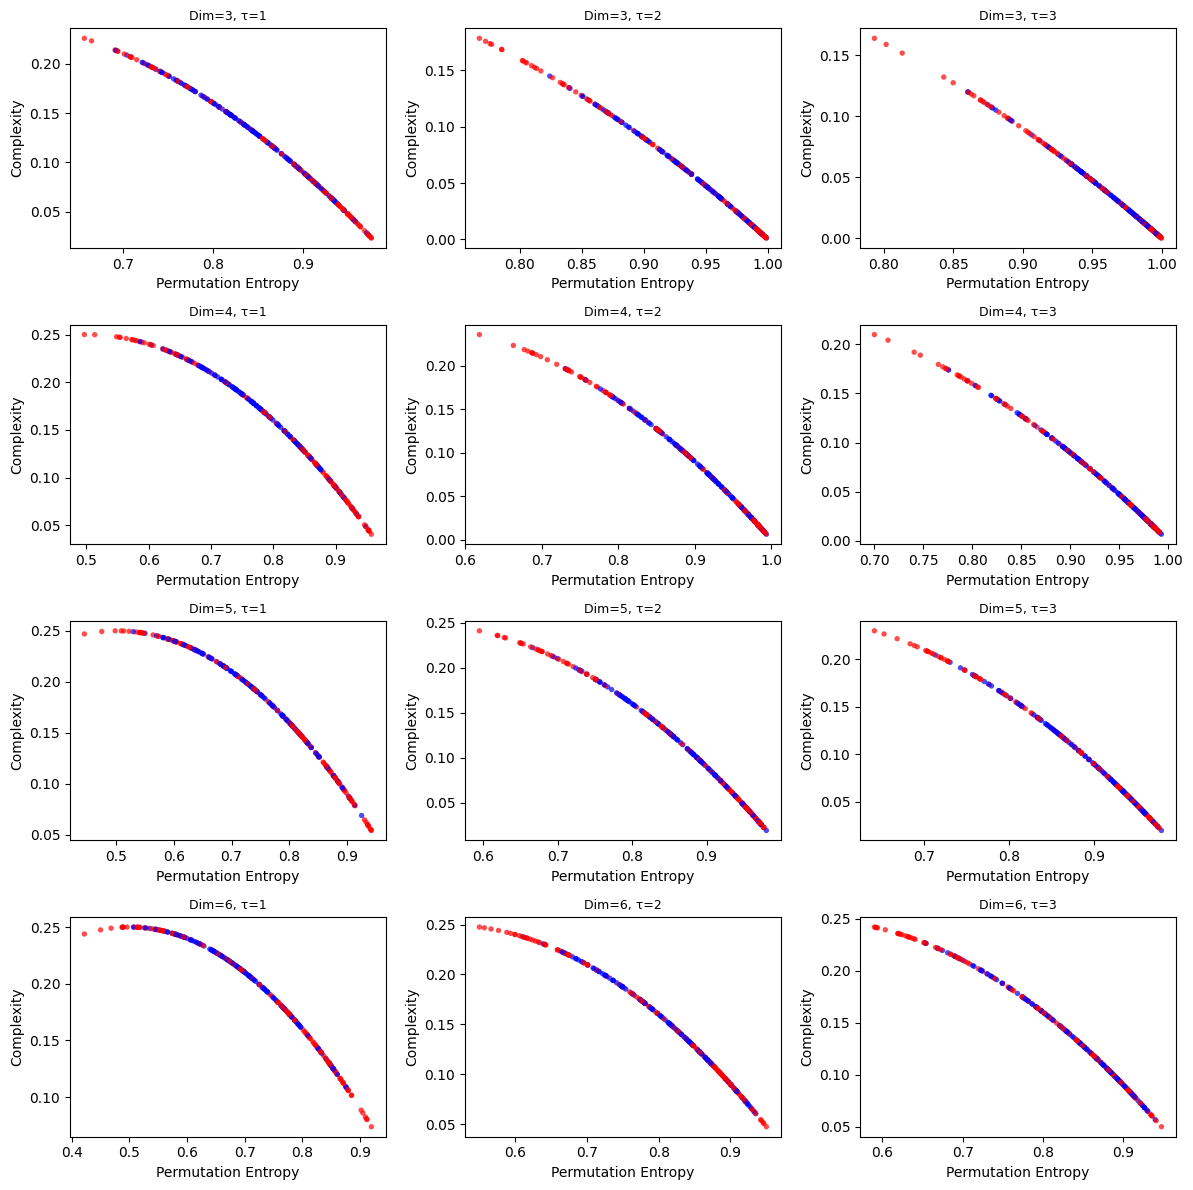

In [24]:
# TASK 4 – Walking vs Running
import matplotlib.pyplot as plt

# Filter for 'walking' and 'running' activities
walkrun = feature_df[feature_df.Activity.isin(['walking', 'running'])]

# Create subplots for scatter plots
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.flatten()

k = 0
for m in [3, 4, 5, 6]:
    for tau in [1, 2, 3]:
        # Filter for current dimension and delay
        df = walkrun[
            (walkrun.Dim.astype(int) == m) &
            (walkrun.Delay.astype(int) == tau)
        ]
        ax = axes[k]

        if not df.empty:
            # Create scatter plot
            ax.scatter(
                df.PE, df.C,
                c=df.Activity.map({'walking': 'blue', 'running': 'red'}),
                s=15, alpha=0.7, edgecolor='none'
            )
        ax.set_title(f'Dim={m}, τ={tau}', fontsize=9)
        ax.set_xlabel('Permutation Entropy')
        ax.set_ylabel('Complexity')
        k += 1

plt.tight_layout()
plt.show()

The plot of Dim=5 and $\tau=1$ show the cleanest and most distinct separation. The blue dots form a tight, isolated cluster. The red dots are cleanly separated into two distinct groups at a lower and a higher permutation entropy with little overlap with the blue cluster.

### Task 5: Climbing Up vs. Climbing Down

Use scatter plots similar to task 4 to identify the optimal dimension and delay that best separate climbing up from climbing down.


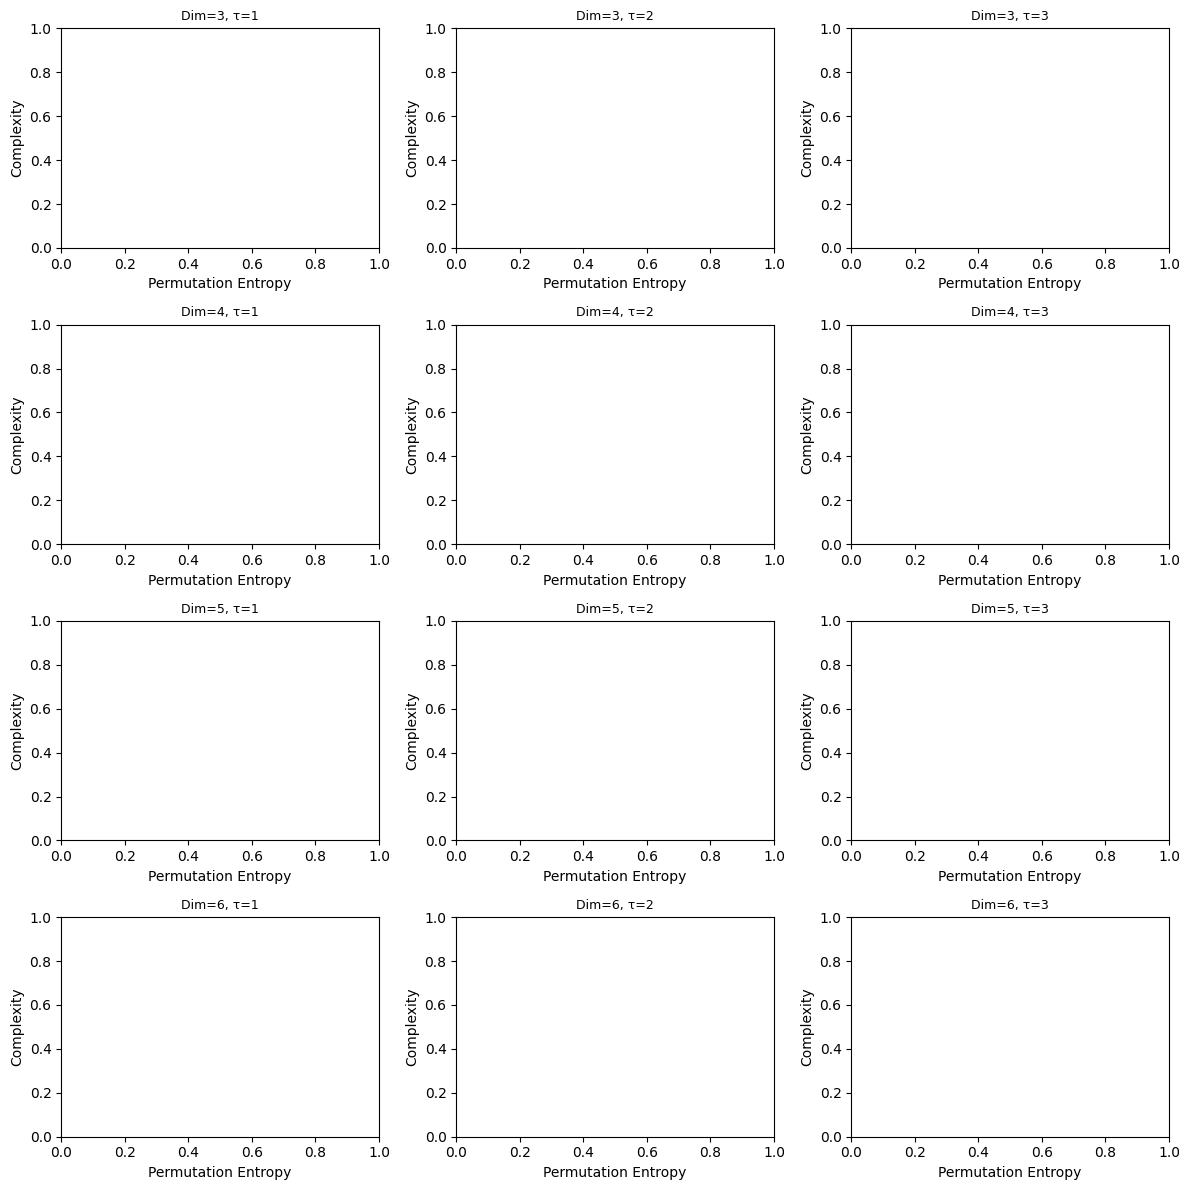

In [25]:
# TASK 5 – Climbing Up vs. Climbing Down
import matplotlib.pyplot as plt

# Filter for 'climbingup' and 'climbingdown' activities
climb = feature_df[feature_df.Activity.isin(['climbingup', 'climbingdown'])]

# Create subplots for scatter plots
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.flatten()

k = 0
for m in [3, 4, 5, 6]:
    for tau in [1, 2, 3]:
        # Filter for current dimension and delay
        df = climb[
            (climb.Dim.astype(int) == m) &
            (climb.Delay.astype(int) == tau)
        ]
        ax = axes[k]

        if not df.empty:
            # Create scatter plot
            ax.scatter(
                df.PE, df.C,
                c=df.Activity.map({'climbingup': 'green', 'climbingdown': 'orange'}),
                s=15, alpha=0.7, edgecolor='none'
            )
        ax.set_title(f'Dim={m}, τ={tau}', fontsize=9)
        ax.set_xlabel('Permutation Entropy')
        ax.set_ylabel('Complexity')
        k += 1

plt.tight_layout()
plt.show()

he plot of Dim=6 and  τ=3  show the cleanest and most distinct separation. We can see that there are 2 green clusters and 2 yellow clusters. It starts with a large green cluster followed by a small yellow cluster than a small green cluster and finally a large yellow cluster.

## Submitting your Project

Once you've completed your project, it's time to submit your work for grading.   
This week, you will submit your code file `Project 2.ipynb` for review.  

In order to submit your work, please follow the steps below:
1. Verify you've saved your work using the `Save` button within the Jupyter Notebook
2. Download this notebook using the `File` -> `Download As` -> Choose the `Notebook (.ipynb)` format.
3. Access the following Step 2: Submit Project 2 item.
4. Complete all prompted fields, and upload your Jupyter Notebook file (Project 2.ipynb) in the indicated field.
5. Submit your notebook to "Step 2: Submit Project 2" by the deadline indicated within your course view for the Project 2 Assignment item.

## Grading Rubric

1. Task 1 = 5 points


2. Task 2 = 35 points


3. Task 3 = 10 points


4. Task 4 = 20 points


5. Task 5 = 20 points


6. 10 points for coding consistencies (follow PeP 8 style guide for coding)

    a. Proper commenting
    
    b. Proper variable names
    
    c. Inclusion of texts in notebook to explain all the steps
    
    d. Include formulas for permutation entropy and complexity in your notebook

    e. Inclusion of all outputs of your code

Congratulations on completing the Project 2 Assignment!